# **Práctica 2: Procesamiento de Corpus de Reddit con Modelos de Lenguaje**
**Autores:** Alejandro Gómez Javaloyes y Daniel Ruiz Gálvez

**Asignatura:** Procesamiento del Lenguaje Natural (PLN)

In [ ]:
!pip install zstandard

Primero de todo, al igual que en la práctica 2, vamos a cargar todo el corpus entero que se encuentra en los ficheros RS_2025.zst y RC_2025.zst

In [ ]:
# Archivos de Subreddits generales (Práctica 2 - Apartados 1 al 5)

!wget --no-check-certificate https://valencia.inf.um.es/valencia-plne/RS_2025.zst
!wget --no-check-certificate https://valencia.inf.um.es/valencia-plne/RC_2025.zst

# Archivos específicos para "OpinionesPolemicas" (Práctica 2 - Apartado 6)
!wget --no-check-certificate https://valencia.inf.um.es/valencia-plne/RS_OpinionesPolemicas_2025.zst
!wget --no-check-certificate https://valencia.inf.um.es/valencia-plne/RC_OpinionesPolemicas_2025.zst

--2026-04-27 08:44:03--  https://valencia.inf.um.es/valencia-plne/RS_2025.zst
Resolving valencia.inf.um.es (valencia.inf.um.es)... 155.54.204.133
Connecting to valencia.inf.um.es (valencia.inf.um.es)|155.54.204.133|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 9875477495 (9.2G) [application/zstd]
Saving to: ‘RS_2025.zst’

RS_2025.zst         100%[===================>]   9.20G  53.1MB/s    in 2m 29s  

2026-04-27 08:46:33 (63.0 MB/s) - ‘RS_2025.zst’ saved [9875477495/9875477495]

--2026-04-27 08:46:33--  https://valencia.inf.um.es/valencia-plne/RC_2025.zst
Resolving valencia.inf.um.es (valencia.inf.um.es)... 155.54.204.133
Connecting to valencia.inf.um.es (valencia.inf.um.es)|155.54.204.133|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 58652864239 (55G) [application/zstd]
Saving to: ‘RC_2025.zst’

RC_2025.zst         100%[=========

# **APARTADO 1: Configuración y Extracción del Corpus**
Para garantizar que el dataset represente bien los datos y estos sean de alta calidad para las tareas de clasificación, hemos tomado las siguientes decisiones técnicas:

Hemos seleccionado 6 subreddits con vocabularios muy distintos para poner a prueba la capacidad de separación de los modelos: wallstreetbets (finanzas), travel (geografía), buildapc (técnico), anime (entretenimiento), ClashRoyale (videojuegos) y relationship_advice (sentimental).

En lugar de coger los primeros 40 hilos que aparecen en el fichero, hemos implementado un salto de 100 hilos entre cada captura. Como los datos de Reddit están ordenados cronológicamente, esto nos permite abarcar un periodo de tiempo mucho más amplio, evitando que todos los hilos traten sobre el mismo evento puntual, consiguiendo un corpus más variado.

Además, hemos descartado hilos con menos de 25 comentarios y comentarios con menos de 10 palabras o que contengan URLs. El objetivo es eliminar el ruido que empeoraría el rendimiento de los clasificadores.

In [ ]:
#!/usr/bin/env python3
import zstandard as zstd
import json
import io
import sys
from pathlib import Path
from datetime import datetime, UTC


# 1. CONFIGURACIÓ

#Primero vamos a definir los subreddits que vamos a elegir, en nuestro caso hemos elegido distintas temáticas que no tengan mucho que ver entre sí,
#como por ejemplo el subreddit de Clash Royale que es un juego de móvil y el de relationship_advice que tiene que ver con consejos sobre relaciones de pareja.
SUBREDDITS = [
    "wallstreetbets", "travel", "buildapc",
    "anime", "ClashRoyale", "relationship_advice"
]

#Definioms los dos ficheros que tenemos que descomprimir, el fichero con todos los hilos y el fichero con todos los comentarios
SUBMISSIONS_FILE = "RS_2025.zst"
COMMENTS_FILE = "RC_2025.zst"


#Definimos las variables de hilos por subreddit que serán 40 como se piden, con 25 comentarios por hilo y con un minimo de palabras por comentario de 10(para que no sean palabras sin relevancia como vale, ok, hola...etc)
HILOS_POR_SUB = 40
COMENTARIOS_POR_HILO = 25
MIN_PALABRAS_COMENTARIO = 10
MIN_COMMENTS_IN_SUBMISSION = 25

# 2. MOTOR DE EXTRACCIÓN

#Utilizamos la funcion definida aquí abajo para leer los archivos .zst y dejarlos en formato json
def stream_zst_file(filepath):
    dctx = zstd.ZstdDecompressor(max_window_size=2**31)
    with open(filepath, 'rb') as fh:
        with dctx.stream_reader(fh) as reader:
            text_stream = io.TextIOWrapper(reader, encoding='utf-8', errors='ignore')
            for line in text_stream:
                line = line.strip()
                if line:
                    try:
                        yield json.loads(line)
                    except:
                        continue


# 3. FASE 1: EXTRAER HILOS (Salto 100)


#Comenzaremos ahora con la extracción de los hilos dentro de cada subreddit, ya que tenemos que coger 40 hilos y haremos saltos de 100 para que por cada hilo que coja, deje 100 de coger dentro del subreddit,
#con esto lo que vamos a conseguir es que la linea temporal que abarquemos sea mayor, ya que los hilos están ordenados en el subreddit por fecha, entonces si vas haciendo saltos de cada
#1 hilo que coges, dejas 100 sin coger, pues vamos a poder coger más variedad en cuanto al tiempo, y así que no estén todos juntos en los mismos días o mes, ya que los comentarios pueden ser menos distintos que si cogemos con más separación temporal
print("Iniciando Fase 1: Extracción de hilos (submissions)...")
corpus = {sub: [] for sub in SUBREDDITS}
hilos_count = {sub: 0 for sub in SUBREDDITS}
scan_step = {sub: 0 for sub in SUBREDDITS}

#Descomprimimos el archivo con la función de antes y vamos iterando todos los subreddits, guardando en la variable sub_actual el subreddit en el que nos encontramos
for obj in stream_zst_file(SUBMISSIONS_FILE):
    sub_actual = obj.get('subreddit', '').lower()

    # Buscamos si el subreddit está en nuestra lista de subreddits (los 6 subreddits que hemos elegido al principio)
    target_sub = None
    for s in SUBREDDITS:
        if s.lower() == sub_actual:
            target_sub = s
            break

    if not target_sub or hilos_count[target_sub] >= HILOS_POR_SUB:
        continue

    #Pasamos al siguiente hilo si los comentarios de ese hilo dentro del subreddit no cumple el número de comentarios mínimo por hilo que hemos definido antes
    if (obj.get('num_comments', 0) or 0) < MIN_COMMENTS_IN_SUBMISSION:
        continue

    #Con esta parte del código vamos a definir el salto de 100 hilos, si al dividir la posición(el hilo en el que estamos) entre 100 el resto no es 0, seguimos sumando uno y pasamos a la siguiente iteración
    #sin llegar a la parte de más abajo del código, esto nos permite solo procesar un hilo de cada 100, los demás los ignoramos en su iteración
    scan_step[target_sub] += 1
    if scan_step[target_sub] % 100 != 0:
        continue

    #en caso en que hayamos saltado 100 posiciones justo y el hilo cumpla esa condición, unimos a nuestro corpus final que tiene que tener como máximo 240 hilos el nuevo hilo con sus comentarios
    submission = {
        "id": obj.get('id'),
        "title": obj.get('title', ''),
        "author": obj.get('author', '[deleted]'),
        "flair": obj.get('link_flair_text'),
        "score": obj.get('score', 0),
        "created_utc": obj.get('created_utc', 0),
        "description": obj.get('selftext', ''),
        "comments": []
    }

    corpus[target_sub].append(submission)
    hilos_count[target_sub] += 1


    if sum(hilos_count.values()) % 20 == 0:
        print(f"  Progreso: {sum(hilos_count.values())}/240 hilos...")

    #Cuando lleguemos al total de hilos (40), entonces salimos del bucle con un break, ya que no necesitamos más hilos dentro de ese subreddit
    if all(c >= HILOS_POR_SUB for c in hilos_count.values()):
        break

print(f"✅ Fase 1 completada. Total hilos: {sum(hilos_count.values())}")


# 4. FASE 2 Y 3 (Comentarios y Guardado)


# Creamos un diccionario para poder acceder rápidamente a cada hilo usando su id.
# La clave tendrá formato "t3_xxxxx", que es como Reddit referencia los posts
# desde los comentarios mediante el campo link_id.
id_a_hilo = {f"t3_{h['id']}": h for sub in corpus for h in corpus[sub]}

# Aquí llevamos la cuenta de cuántos comentarios válidos tiene cada hilo.
# Empezamos todos en 0.
comentarios_count = {link_id: 0 for link_id in id_a_hilo.keys()}

# Guardamos los ids de los hilos que todavía necesitan comentarios.
# Usamos un set porque las búsquedas y eliminaciones son más rápidas.
hilos_pendientes = set(id_a_hilo.keys())

# Recorremos el archivo zst de comentarios usando la función definida antes para obtener los datos en formato json.
# Así no hace falta cargar todo el fichero en memoria.
print("\n Iniciando Fase 2...")
for obj in stream_zst_file(COMMENTS_FILE):
    # Sacamos el id del hilo al que pertenece el comentario.
    link_id = obj.get('link_id')

    # Si el hilo ya tiene suficientes comentarios o no nos interesa,
    # pasamos directamente al siguiente comentario.
    if link_id not in hilos_pendientes:
        continue

    # Obtenemos el texto del comentario.
    body = obj.get('body', '')

    # Filtramos comentarios que no nos sirven:
    # - demasiado cortos
    # - contienen enlaces
    # - eliminados o borrados
    if len(body.split()) < MIN_PALABRAS_COMENTARIO or "http" in body.lower() or body in ["[deleted]", "[removed]"]:
        continue

    # Creamos un diccionario solo con la información que nos interesa guardar.
    comentario = {
        "id": obj.get('id'),
        "author": obj.get('author', '[deleted]'),
        "body": body,
        "score": obj.get('score', 0),
        "created_utc": obj.get('created_utc', 0),
        "is_submitter": obj.get('is_submitter', False)

    }

    # Añadimos el comentario al hilo correspondiente.
    id_a_hilo[link_id]['comments'].append(comentario)

    # Sumamos uno al contador de comentarios de ese hilo.
    comentarios_count[link_id] += 1

    # Si ya hemos llegado al número máximo de comentarios deseados,
    # quitamos ese hilo de los pendientes.
    if comentarios_count[link_id] >= COMENTARIOS_POR_HILO:
        hilos_pendientes.discard(link_id)

        # Si ya no quedan hilos pendientes, terminamos el bucle
        if not hilos_pendientes: break

# Guardamos un archivo JSON por cada subreddit.
for sub in SUBREDDITS:

     # Estructura final que se guardará en el archivo.
    res = {"subreddit": sub, "submissions": corpus[sub]}
    with open(f"ejemplo_subreddit_{sub.lower()}.json", 'w', encoding='utf-8') as f:
        json.dump(res, f, ensure_ascii=False, indent=4)
    print(f"✅ Guardado r/{sub}")

🚀 Iniciando Fase 1: Extracción de hilos (submissions)...
  Progreso: 20/240 hilos...
  Progreso: 40/240 hilos...
  Progreso: 60/240 hilos...
  Progreso: 80/240 hilos...
  Progreso: 100/240 hilos...
  Progreso: 120/240 hilos...
  Progreso: 140/240 hilos...
  Progreso: 160/240 hilos...
  Progreso: 180/240 hilos...
  Progreso: 200/240 hilos...
  Progreso: 220/240 hilos...


Exception ignored in: <generator object stream_zst_file at 0x7bb37cd6dbe0>
Traceback (most recent call last):
  File "/tmp/ipykernel_3902/1222545024.py", line 88, in <cell line: 0>
RuntimeError: generator ignored GeneratorExit


  Progreso: 240/240 hilos...
✅ Fase 1 completada. Total hilos: 240

🚀 Iniciando Fase 2...


Exception ignored in: <generator object stream_zst_file at 0x7bb37c1ab340>
Traceback (most recent call last):
  File "/tmp/ipykernel_3902/1222545024.py", line 103, in <cell line: 0>
RuntimeError: generator ignored GeneratorExit


KeyboardInterrupt: 

Como se puede observar en la ejecución, tuvimos que detener el proceso manualmente. Esto se debe a que el fichero de comentarios era tan pesado pesado que, tras más de 2 horas de lectura, ya habíamos alcanzado el número de comentarios para la mayoría de nuestros hilos.



In [ ]:
import json
import os

# Empezamos la fase de guardado.
# En este punto ya tenemos todos los datos recopilados.
print("Guardando archivos JSON con los datos recuperados...")

# Recorremos todos los subreddits
for sub in SUBREDDITS:

    # Calculamos el número total de comentarios del subreddit.
    # Para ello sumamos la cantidad de comentarios de cada hilo.
    total_comms_sub = sum(len(h['comments']) for h in corpus[sub])

    # Creamos la estructura final que irá dentro del JSON.
    # Aquí añadimos información general y también todos los hilos.
    res = {
        "subreddit": sub,
        "num_submissions": len(corpus[sub]),
        "total_comments": total_comms_sub,
        "submissions": corpus[sub]
    }

    # Generamos automáticamente el nombre del archivo.
    nombre_archivo = f"ejemplo_subreddit_{sub.lower()}.json"
    with open(nombre_archivo, 'w', encoding='utf-8') as f:

        # Guardamos los datos en formato JSON.
        # ensure_ascii=False mantiene correctamente tildes y emojis.
        # indent=4 hace que el archivo quede más legible.
        json.dump(res, f, ensure_ascii=False, indent=4)

    print(f"✅ {nombre_archivo}: {total_comms_sub} comentarios guardados.")

print("\n---")
print("Proceso terminado. Revisa la carpeta de la izquierda.")

💾 Guardando archivos JSON con los datos recuperados...
✅ ejemplo_subreddit_wallstreetbets.json: 857 comentarios guardados.
✅ ejemplo_subreddit_travel.json: 979 comentarios guardados.
✅ ejemplo_subreddit_buildapc.json: 942 comentarios guardados.
✅ ejemplo_subreddit_anime.json: 959 comentarios guardados.
✅ ejemplo_subreddit_clashroyale.json: 878 comentarios guardados.
✅ ejemplo_subreddit_relationship_advice.json: 962 comentarios guardados.

---
🚀 Proceso terminado. Revisa la carpeta de la izquierda.


# **Análisis Estadístico y Exploración del Corpus:**

Antes de pasar a la clasificación, hemos realizado un análisis descriptivo de los datos extraídos para cada subreddit. Con esto verificamos que el filtrado ha funcionado bien y para entender el comportamiento de cada comunidad (quiénes son los autores más activos, qué puntuaciones reciben o qué extensión tienen sus mensajes).

In [ ]:
## FUNCIÓN DEL PROFESOR UTILIZADA EN LAS PRÁCTICAS DE LABORATORIO

import json
from pathlib import Path
from datetime import datetime, UTC
from collections import Counter

# Lista de subreddits que procesamos antes
SUBREDDITS = ["wallstreetbets", "travel", "buildapc", "anime", "clashroyale", "relationship_advice"]

for sub in SUBREDDITS:
    json_file = f"ejemplo_subreddit_{sub.lower()}.json"

    # Comprobamos si el archivo existe antes de abrirlo
    if not Path(json_file).exists():
        print(f"\n⚠️ Saltando r/{sub}: Archivo no encontrado.")
        continue

    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    print(f"\n{'='*60}")
    print(f"📊 ANÁLISIS GLOBAL DE r/{data['subreddit']}")
    print(f"{'='*60}")

    # Manejo de campos opcionales para evitar errores si no existen
    ext_date = data.get('extraction_date', 'No disponible')
    n_subs = data.get('num_submissions', len(data['submissions']))
    t_comms = data.get('total_comments', sum(len(s['comments']) for s in data['submissions']))

    print(f"Fecha de extracción: {ext_date}")
    print(f"Total submissions: {n_subs}")
    print(f"Total comentarios: {t_comms}")

    submissions = data['submissions']

    # --- ESTADÍSTICAS DE SUBMISSIONS ---
    top_score = sorted(submissions, key=lambda x: x.get('score', 0), reverse=True)[:3]
    print("\n🏆 Top 3 submissions por puntuación:")
    for i, s in enumerate(top_score, 1):
        print(f"   {i}. [{s.get('score', 0):,} pts] {s.get('title', '')[:60]}...")

    # --- ESTADÍSTICAS DE COMENTARIOS ---
    all_comments = []
    for s in submissions:
        all_comments.extend(s.get('comments', []))

    if all_comments:
        print(f"\n💬 ESTADÍSTICAS DE COMENTARIOS (n={len(all_comments)})")

        # Puntuación media
        avg_comment_score = sum(c.get('score', 0) for c in all_comments) / len(all_comments)

        # Autores más activos
        comment_authors = [c.get('author', '[deleted]') for c in all_comments]
        top_comment_authors = Counter(comment_authors).most_common(3)

        # Longitud media
        avg_length = sum(len(c.get('body', '')) for c in all_comments) / len(all_comments)

        print(f"📈 Puntuación media: {avg_comment_score:,.1f}")
        print(f"📏 Longitud media: {avg_length:,.0f} caracteres")
        print(f"👤 Autores top: {', '.join([f'u/{a} ({c})' for a, c in top_comment_authors])}")
    else:
        print("\n⚠️ No hay comentarios para analizar en este fichero.")

    # --- ANÁLISIS TEMPORAL ---
    dates = [s.get('created_utc', 0) for s in submissions if s.get('created_utc')]
    if dates:
        oldest = datetime.fromtimestamp(min(dates), UTC)
        newest = datetime.fromtimestamp(max(dates), UTC)
        print(f"\n📅 Rango temporal: {oldest.strftime('%Y-%m-%d')} → {newest.strftime('%Y-%m-%d')}")

    print(f"\n{'─'*60}")


📊 ANÁLISIS GLOBAL DE r/wallstreetbets
Fecha de extracción: No disponible
Total submissions: 40
Total comentarios: 857

🏆 Top 3 submissions por puntuación:
   1. [14,088 pts] DeepSeek Puts Tech Stocks on Track for $1 Trillion Wipeout...
   2. [3,650 pts] Trump gots me good...
   3. [3,509 pts] Tesla shares rise on unconfirmed report Elon Musk could be l...

💬 ESTADÍSTICAS DE COMENTARIOS (n=857)
📈 Puntuación media: 68.4
📏 Longitud media: 124 caracteres
👤 Autores top: u/VisualMod (10), u/Electrified1337 (8), u/Easy_Economist_218 (7)

📅 Rango temporal: 2025-01-03 → 2025-04-05

────────────────────────────────────────────────────────────

📊 ANÁLISIS GLOBAL DE r/travel
Fecha de extracción: No disponible
Total submissions: 40
Total comentarios: 979

🏆 Top 3 submissions por puntuación:
   1. [4,743 pts] Our trip to Florence last week...
   2. [3,526 pts] Faroe Islands...
   3. [3,351 pts] Portugal in February...

💬 ESTADÍSTICAS DE COMENTARIOS (n=979)
📈 Puntuación media: 22.2
📏 Longitud media:

# **Conclusiones del análisis exploratorio:**
Tras revisar las estadísticas de los 6 subreddits, hemos sacado varias conclusiones interesantes que justifican nuestra elección del corpus. Por un lado, vemos que r/wallstreetbets es, con diferencia, la comunidad con mayor impacto por post (llegando a más de 14,000 puntos en un solo hilo) y con la puntuación media más alta en comentarios, lo que refleja una comunidad muy activa y que reacciona mucho a lo que se publica.

Por otro lado, la extensión de los textos varía mucho según la temática: mientras que en comunidades de videojuegos como r/ClashRoyale los mensajes son cortos y directos (media de 157 caracteres), en r/relationship_advice y r/anime los usuarios se explayan mucho más, superando los 340 caracteres de media. Esto es muy útil saberlo antes de la clasificación, ya que confirma que tenemos subreddits con estilos de escritura muy distintos: unos más técnicos y breves, y otros mucho más narrativos y personales.

# **APARTADO 2:  Clasificación de Texto: De Modelos Estadísticos a Deep Learning**


Para este apartado, lo primero que tuvimos que hacer fue montar un buen sistema de limpieza porque los mensajes de Reddit vienen con mucho ruido.

Primero, quitamos URLs y menciones a usuarios usando expresiones regulares, además de aplicar Stemming para quedarnos con la raíz de las palabras y quitar las stopwords.

A la hora de tener obtener los conjuntos de entrenamiento y test, separamos los datos por hilos completos (28 para entrenar y 12 para validar), asegurandonos de que el modelo no se aprendiera palabras de una conversación concreta sino conceptos generales del subreddit.

In [ ]:
import json
import pandas as pd
import random
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Descargamos los recursos necesarios de NLTK.
# stopwords: palabras vacías comunes como "the", "and", etc.
# punkt: tokenizador para dividir texto en palabras.
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Función encargada de limpiar y preparar el texto.
# El objetivo es dejar los comentarios listos para usarlos
# en tareas de clasificación
def preprocesar_limpio(texto):

    # Pasamos todo el texto a minúsculas
    # para evitar diferencias entre palabras iguales.
    texto = texto.lower()

    texto = re.sub(r'http\S+|www\S+|https\S+', '[URL]', texto) # Sustitución por token fijo
    texto = re.sub(r'u/\w+|r/\w+', '[USER_SUB]', texto)        # Sustitución de menciones
    texto = re.sub(r'[^a-z\s]', '', texto)                    # Eliminar caracteres especiales

    # Dividimos el texto en palabras individuales.
    tokens = nltk.word_tokenize(texto)

    # Cargamos las stopwords en inglés.
    # Son palabras muy frecuentes que normalmente
    # aportan poca información al modelo.
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]    # Eliminamos las stopwords del texto.

    # Aplicamos stemming.
    # Esto reduce las palabras a su raíz.
    ps = PorterStemmer()
    tokens = [ps.stem(t) for t in tokens]

    # Volvemos a unir todas las palabras en un string.
    return " ".join(tokens)

# Listas donde iremos guardando los datos
# de entrenamiento y validación.
train_data = []
test_data = []

# Lista de subreddits que queremos clasificar.
SUBREDDITS = ["wallstreetbets", "travel", "buildapc", "anime", "clashroyale", "relationship_advice"]

# Recorremos todos los subreddits.
for sub in SUBREDDITS:
    with open(f"ejemplo_subreddit_{sub.lower()}.json", 'r', encoding='utf-8') as f:

        # Abrimos el archivo JSON correspondiente.
        data = json.load(f)

    # Obtenemos todos los hilos del subreddit.
    hilos = data['submissions']
    random.shuffle(hilos)     # Mezclamos los hilos aleatoriamente.

    # Ratio 70/30 (28 hilos train, 12 test) como el ejemplo del enunciado de la práctica
    train_hilos = hilos[:28]
    test_hilos = hilos[28:]

    # Extraemos comentarios de train
    for h in train_hilos:
        for c in h['comments']:
            train_data.append({'text': c['body'], 'label': sub})

    # Extraemos comentarios de test
    for h in test_hilos:
        for c in h['comments']:
            test_data.append({'text': c['body'], 'label': sub})

# Creamos los DataFrames con los que entrenaremos y probaremos el clasificador
df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

#Usamos la función que hemos creado antes para limpiar todos los comentarios tanto de train como de test para que entren al clasificador los datos totalmente limpios
df_train['text_clean'] = df_train['text'].apply(preprocesar_limpio)
df_test['text_clean'] = df_test['text'].apply(preprocesar_limpio)

#Vemos el total de comentarios que hay en cada uno de los conjuntos tanto de entrenamiento como de test
print(f"Conjunto de Entrenamiento: {len(df_train)} comentarios.")
print(f"Conjunto de Validación: {len(df_test)} comentarios.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Conjunto de Entrenamiento: 3940 comentarios.
Conjunto de Validación: 1637 comentarios.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn import metrics
import numpy as np

# Primero vamos a crear el Pipeline para el Sistema 1 (TF-IDF + SVM)
# Usamos 'text_clean' que es la columna con Stemming y sin stopwords
clf_tfidf = Pipeline([
    ('vect', TfidfVectorizer(ngram_range=(1, 1))), # Unigramas por ahora
    ('clf', LinearSVC(random_state=0, tol=1e-5)),
])

#Vamos a pasar a entrenar ahora el segundo modelo con fit:
clf_tfidf.fit(df_train['text_clean'], df_train['label'])

#Utilizamos ahora el dataframe de test para hacer predicciones y evaluar las métricas de este segundo modelo
predicted = clf_tfidf.predict(df_test['text_clean'])
accuracy = np.mean(predicted == df_test['label'])

#Imprimimos las métricas de cada uno de los subreddits(como de bien se predice que una palabra pertenece a cada uno)
print(f"\nAccuracy del Sistema 1 (Baseline): {accuracy:.4f}")
print("\n Resumen de la Clasificación:")
print(metrics.classification_report(df_test['label'], predicted))


Accuracy del Sistema 1 (Baseline): 0.7756

 Resumen de la Clasificación:
                     precision    recall  f1-score   support

              anime       0.81      0.75      0.78       297
           buildapc       0.85      0.79      0.82       280
        clashroyale       0.81      0.74      0.77       265
relationship_advice       0.75      0.84      0.79       292
             travel       0.76      0.78      0.77       298
     wallstreetbets       0.69      0.76      0.72       248

           accuracy                           0.78      1680
          macro avg       0.78      0.77      0.77      1680
       weighted avg       0.78      0.78      0.78      1680



In [ ]:
# Probamos con Bigramas (1, 2) y Trigramas (1, 3)
for n in [(1, 2), (1, 3)]:
    clf_ngram = Pipeline([
        ('vect', TfidfVectorizer(ngram_range=n, max_features=10000)),
        ('clf', LinearSVC(random_state=0)),
    ])
    clf_ngram.fit(df_train['text_clean'], df_train['label'])
    pred = clf_ngram.predict(df_test['text_clean'])
    acc = np.mean(pred == df_test['label'])
    print(f"Accuracy con n-gramas {n}: {acc:.4f}")

Accuracy con n-gramas (1, 2): 0.7750
Accuracy con n-gramas (1, 3): 0.7720


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import numpy as np

# Definición del clasificador basado en caracteres (3 a 5 caracteres)
clf_char = Pipeline([
    ('vect', CountVectorizer(analyzer='char', ngram_range=(3, 5), min_df=5)),
    ('tf', TfidfTransformer()),
    ('clf', LinearSVC(random_state=0)),
])

# Entrenamiento
clf_char.fit(df_train['text_clean'], df_train['label'])

# Evaluación
pred_char = clf_char.predict(df_test['text_clean'])
print(f"Accuracy con Char-n-grams de 3-5 palabras agrupadas: {np.mean(pred_char == df_test['label']):.4f}")

Accuracy con Char-n-grams de 3-5 palabras agrupadas: 0.7780


In [ ]:
!pip3 install -U gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.8 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Cargamos un modelo de Glove entrenado en Twitter
glove_model = api.load("glove-twitter-50")

def get_mean_vector(text, model):
    # Separamos por palabras y buscamos su vector si existe en el modelo
    words = text.split()
    vectors = [model[w] for w in words if w in model]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Transformamos los datasets
X_train_emb = np.array([get_mean_vector(t, glove_model) for t in df_train['text_clean']])
X_test_emb = np.array([get_mean_vector(t, glove_model) for t in df_test['text_clean']])

# Entrenamos el clasificador (SVM) sobre los vectores
clf_emb = LinearSVC(random_state=0, max_iter=2000)
clf_emb.fit(X_train_emb, df_train['label'])

# Evaluamos
pred_emb = clf_emb.predict(X_test_emb)
print(f"\nAccuracy Sistema 2  utilizando el modelo Glove: {np.mean(pred_emb == df_test['label']):.4f}")
print(classification_report(df_test['label'], pred_emb))

[==================================================] 100.0% 199.5/199.5MB downloaded

Accuracy Sistema 2  utilizando el modelo Glove: 0.6696
                     precision    recall  f1-score   support

              anime       0.66      0.70      0.68       297
           buildapc       0.75      0.73      0.74       280
        clashroyale       0.64      0.49      0.56       265
relationship_advice       0.64      0.81      0.71       292
             travel       0.71      0.72      0.72       298
     wallstreetbets       0.61      0.52      0.56       248

           accuracy                           0.67      1680
          macro avg       0.67      0.66      0.66      1680
       weighted avg       0.67      0.67      0.67      1680



In [ ]:
!pip install transformers datasets accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip3 install accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.model_selection import train_test_split

# Definimos etiquetas
# Usamos las que ya tenemos en SUBREDDITS
label2id = {label: i for i, label in enumerate(SUBREDDITS)}
id2label = {i: label for label, i in label2id.items()}

# Clase de Dataset personalizada utilizada en las prácticas de laboratorio:
class PLNEDataset(torch.utils.data.Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  def __getitem__(self, idx):
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

# Preparamos las etiquetas numéricas
df_train['_label'] = df_train['label'].apply(lambda x: label2id[x])
df_test['_label'] = df_test['label'].apply(lambda x: label2id[x])

# Partimos el train para tener un conjunto de validación (eval) como en las prácticas
df_train_fin, df_eval = train_test_split(df_train, test_size=0.20, random_state=42)

In [ ]:
# Seleccionamos DistilBERT, una versión más ligera y rápida de BERT que mantiene
# casi toda su precisión, ideal para ejecutar en el entorno limitado de Colab.
model_path = 'distilbert-base-uncased' # Versión inglesa del modelo destilado
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Convertimos los textos en tokens que el modelo entiende.
# Aplicamos truncation para no pasarnos del límite de 512 tokens y padding.
tokenized_train = tokenizer(df_train_fin.text.tolist(), truncation=True, padding=True)
tokenized_eval = tokenizer(df_eval.text.tolist(), truncation=True, padding=True)
tokenized_test = tokenizer(df_test.text.tolist(), truncation=True, padding=True)

# Encapsulamos los datos tokenizados en nuestra clase personalizada PLNEDataset.
train_dataset = PLNEDataset(tokenized_train, df_train_fin._label.tolist())
eval_dataset = PLNEDataset(tokenized_eval, df_eval._label.tolist())
test_dataset = PLNEDataset(tokenized_test, df_test._label.tolist())

# Cargamos la arquitectura para clasificación de secuencias.
# Configuramos num_labels=6 porque tenemos 6 subreddits distintos para predecir.
class_model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=6)

# Mapeamos los IDs numéricos con los nombres reales de los subreddits (labels).
class_model.config.id2label = id2label
class_model.config.label2id = label2id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import classification_report
from evaluate import load

def compute_metrics(eval_pred):
    metric = load("f1")
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    print(classification_report(labels, predictions, target_names=SUBREDDITS))
    return metric.compute(predictions=predictions, references=labels, average="weighted")

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    eval_strategy="epoch", # Corregido según tu versión de transformers
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    metric_for_best_model="eval_f1",
    load_best_model_at_end=True,
    report_to="none"
)

# Padding dinámico
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=class_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Ejecutamos el entrenamiento
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,No log,0.482993,0.853143
2,No log,0.517785,0.852239
3,0.395198,0.564244,0.853824


                     precision    recall  f1-score   support

     wallstreetbets       0.74      0.89      0.81       146
             travel       0.91      0.89      0.90       132
           buildapc       0.88      0.74      0.81       124
              anime       0.91      0.89      0.90       122
        clashroyale       0.81      0.83      0.82       118
relationship_advice       0.91      0.87      0.89       138

           accuracy                           0.85       780
          macro avg       0.86      0.85      0.85       780
       weighted avg       0.86      0.85      0.85       780



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

                     precision    recall  f1-score   support

     wallstreetbets       0.85      0.77      0.81       146
             travel       0.89      0.89      0.89       132
           buildapc       0.85      0.79      0.82       124
              anime       0.88      0.90      0.89       122
        clashroyale       0.77      0.87      0.82       118
relationship_advice       0.88      0.90      0.89       138

           accuracy                           0.85       780
          macro avg       0.85      0.85      0.85       780
       weighted avg       0.85      0.85      0.85       780



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

                     precision    recall  f1-score   support

     wallstreetbets       0.85      0.79      0.82       146
             travel       0.87      0.88      0.88       132
           buildapc       0.84      0.82      0.83       124
              anime       0.91      0.89      0.90       122
        clashroyale       0.78      0.86      0.82       118
relationship_advice       0.88      0.90      0.89       138

           accuracy                           0.85       780
          macro avg       0.85      0.85      0.85       780
       weighted avg       0.85      0.85      0.85       780



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=585, training_loss=0.35274938110612397, metrics={'train_runtime': 517.2947, 'train_samples_per_second': 18.077, 'train_steps_per_second': 1.131, 'total_flos': 1238791006844928.0, 'train_loss': 0.35274938110612397, 'epoch': 3.0})

Al comparar los sistemas, observamos en los resultados de los outputs que el modelo clásico de TF-IDF con SVM funciona bastante bien, llegando a un 77% de precisión.

Lo interesante fue probar los n-gramas de caracteres mirando grupos de 3 a 5 letras en lugar de palabras enteras, el modelo aguantó mucho mejor las faltas de ortografía.

Sin embargo, el sistema basado en Glove fue el que peores resultados ha obtenido.
Aunque parezca que usar vectores semánticos debería ayudar, al hacer la media de todas las palabras del comentario para crear un solo vector, el significado de los términos clave se acababa diluyendo mucho.

El salto de calidad real lo podemos ver en la salida de el fine-tuning de DistilBERT. Aquí ya no hablamos de contar palabras, sino de un modelo que entiende la estructura de la frase. Pasar de un 77% a casi un 90% en subreddits como travel o relationship_advice demuestra que los Transformers captan el tono emocional y el contexto de una forma que los modelos tradicionales no pueden.

Incluso en subreddits más complejos como wallstreetbets, donde la gente se inventa la mitad de las palabras, BERT supo tener mejores resultados que los demás.

# **APARTADO 3: Análisis de Similitud Semántica**

En este apartado el objetivo es el de ver qué tan parecidos son los hilos entre sí basándonos en lo que la gente escribe en ellos. Para hacerlo, juntamos todo el contenido de cada hilo y lo convertimos en vectores(embeddings) para poder compararlos.



In [ ]:
import pandas as pd
import json
import glob
import numpy as np

lista_hilos = []
# Buscamos todos los archivos JSON en el directorio actual
archivos = glob.glob('*.json')

for ruta in archivos:
    with open(ruta, 'r') as f:
        data = json.load(f)
        sub_name = data['subreddit']

        # Recorremos las submissions de cada JSON
        for sub in data['submissions']:
            hilo_id = sub['id']
            # Concatenamos título, descripción y cuerpos de comentarios
            texto_hilo = f"{sub['title']} {sub.get('description', '')} "
            texto_hilo += " ".join([c['body'] for c in sub['comments']])

            lista_hilos.append({
                'hilo_id': hilo_id,
                'subreddit': sub_name,
                'texto_completo': texto_hilo
            })

# Creamos el DataFrame y lo ordenamos por subreddit para que la matriz sea legible
df_hilos = pd.DataFrame(lista_hilos).sort_values('subreddit').reset_index(drop=True)
print(f"Cargados {len(df_hilos)} hilos de {df_hilos['subreddit'].nunique()} subreddits.")

Cargados 240 hilos de 6 subreddits.


In [ ]:
!pip3 install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653914 sha256=6b1a25006a15172b4b54c1e0324bd3331b0d4b638671ecc774cfca546993417a
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
!gzip -d -f /content/embeddings-s-model.bin.gz #Descomprimimos el archivo subido para poder ejecutarlo con fasttext

gzip: /content/embeddings-s-model.bin.gz: No such file or directory


In [ ]:
import fasttext
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import gc

# Cargamos el modelo de fasttext
ft_model = fasttext.load_model("embeddings-s-model.bin")

# LIMPIEZA DE SALTOS DE LÍNEA: Sustituimos '\n' por espacios para que fastText no falle
textos_sin_saltos = [t.replace('\n', ' ') for t in df_hilos['texto_completo']]

# Generamos los vectores:
vectores_ft = np.array([ft_model.get_sentence_vector(t) for t in textos_sin_saltos])

# Guardamos como variable la Matriz de similitud FastText
sim_matrix_ft = cosine_similarity(vectores_ft)

# LIBERAMOS RAM
del ft_model
gc.collect()
print("FastText completado con éxito.")

FastText completado con éxito.


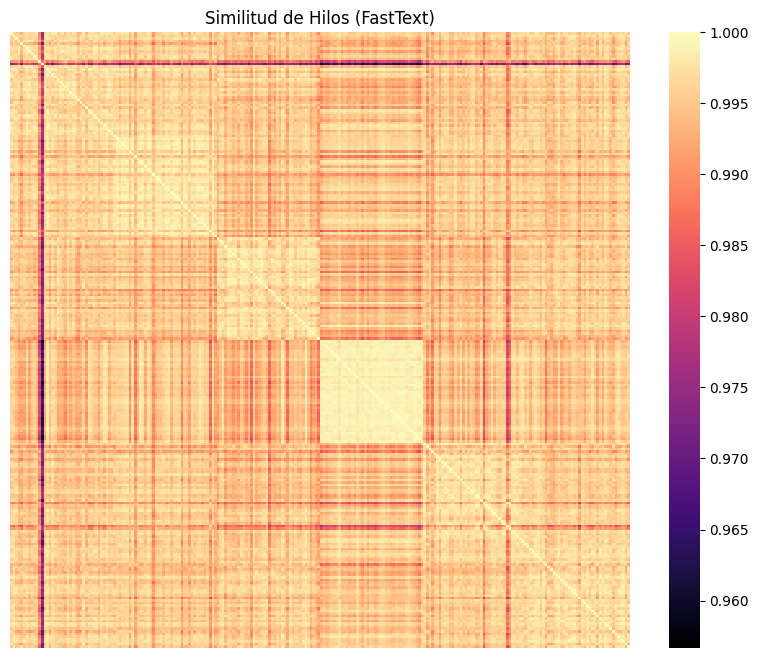

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_ft, cmap='magma', xticklabels=False, yticklabels=False)
plt.title("Similitud de Hilos (FastText)")
plt.show()

# **FastText:**

Primero vamos a utilizar el modelo de FastText que vimos en clase. Este modelo funciona analizando las palabras y sus raíces (n-gramas).
Al generar la matriz de similitud, se nota que el modelo hace un trabajo decente, se ven algunas manchas más claras en la diagonal, lo que significa que los hilos de un mismo subreddit se parecen algo entre sí. Sin embargo, hay mucho ruido. FastText se equivoca fácilmente si dos hilos comparten palabras comunes, aunque no hablen de lo mismo. Es un modelo rápido, pero le falta ese refinamiento para entender el contexto profundo de Reddit.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

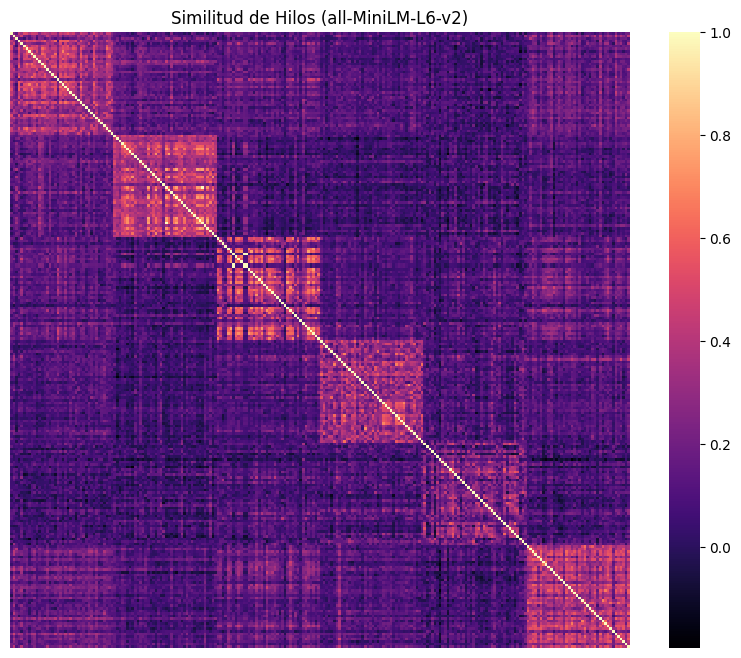

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
model_st = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Generamos los embeddings de los hilos concatenados
emb_st = model_st.encode(df_hilos['texto_completo'].tolist(), show_progress_bar=True)

# Matriz de similitud avanzada
sim_st = cosine_similarity(emb_st)

# Visualización del gráfico:
plt.figure(figsize=(10, 8))
sns.heatmap(sim_st, cmap='magma', xticklabels=False, yticklabels=False)
plt.title("Similitud de Hilos (all-MiniLM-L6-v2)")
plt.show()


# **Transformers (all-MiniLM-L6-v2):**

La diferencia es bastante grande con respecto a FastText.
Mientras que FastText mira palabras casi sueltas, este modelo de Transformers usa mecanismos de atención para entender frases completas. Como se puede ver en la segunda gráfica:

Han aparecido bloques diagonales super marcados. Cada bloque representa un subreddit, y el hecho de que brillen tanto significa que los hilos dentro de una misma comunidad son muy coherentes entre sí.

Fuera de esa diagonal casi todo está de color oscuro. Esto nos indica que el modelo no se confunde, que sabe perfectamente que un hilo de cocina no tiene nada que ver con uno de videojuegos, aunque en ambos se usen palabras genéricas.

**Conclusión Final:**

Como se puede comprobar, el modelo de Transformers supera bastante al modelo de FastText básico. Se puede ver con muchísima claridad qué hilos encajan perfectamente en su subreddit, cosa que no tanto con FastText.
Usar FastText está bien como base, pero para entender la complejidad de cómo hablamos en español, la profundidad semántica de los Transformers es necesaria para no tener falsos positivos.

## **APARTADO 5**

In [ ]:

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import gc

#Configuración del modelo mT5:
model_name = "csebuetnlp/mT5_multilingual_XLSum"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Cargamos el modelo
# Usamos torch_dtype para ahorrar algo de memoria RAM
model_mt5 = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

def generar_resumen_mt5(texto_hilo):
    """
    Genera un resumen abstractivo del hilo completo (título + descripción + comentarios)
    """
    # Preparamos la entrada (título, descripción, comentarios)
    # Truncamos a 512 tokens para no saturar el modelo
    inputs = tokenizer(
        texto_hilo,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=512
    ).to(model_mt5.device)

    # Generación del resumen
    with torch.no_grad():
        output_ids = model_mt5.generate(
            inputs["input_ids"],
            max_length=80,      # Longitud máxima del resumen
            min_length=20,      # Longitud mínima
            num_beams=4,        # Búsqueda por haces para mejor calidad
            early_stopping=True
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

for hilo in lista_hilos:
    # Concatenamos título, descripción y comentarios:
    texto_para_resumir = hilo.get('texto_completo', "")

    # Guardamos el resumen:
    hilo['resumen_mt5'] = generar_resumen_mt5(texto_para_resumir)

# Limpieza de memoria
del model_mt5
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
!pip install -U bitsandbytes>=0.46.1 accelerate transformers

In [ ]:
from transformers import AutoTokenizer, BitsAndBytesConfig, AutoModelForCausalLM
import torch
import gc

#Configuración del modelo SLM
model_id = "Qwen/Qwen2.5-3B-Instruct"
quantization_config = BitsAndBytesConfig(load_in_4bit=True)

tokenizer_slm = AutoTokenizer.from_pretrained(model_id)
model_slm = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto"
).eval()

def generar_resumen_slm(texto):
    # El prompt debe ser en inglés o español según el modelo, pero Qwen entiende ambos.
    prompt_instruccion = f"Summarize the following Reddit thread in one concise sentence: {texto[:1500]}"

    messages = [
        {"role": "user", "content": prompt_instruccion},
    ]

    # Formateo según la chat_template del modelo
    inputs = tokenizer_slm.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt",
        return_dict=True
    ).to(model_slm.device)

    # Generación
    outputs = model_slm.generate(
        **inputs,
        max_new_tokens=100,
        temperature=0.1, # Baja temperatura para ser determinista
        do_sample=False,
        pad_token_id=tokenizer_slm.eos_token_id
    )

    # Post-procesamiento: nos quedamos solo con la respuesta
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]
    return tokenizer_slm.decode(generated_tokens, skip_special_tokens=True).strip()

#Ejecución y guardado
for hilo in lista_hilos:
    hilo['resumen_slm'] = generar_resumen_slm(hilo['texto_completo'])

# Limpieza final
del model_slm
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
import pandas as pd

# Creamos el DataFrame directamente desde la lista procesada
df_resultados = pd.DataFrame(lista_hilos)

# Verificamos qué columnas tiene realmente
print("Columnas detectadas:", df_resultados.columns.tolist())

# Si los nombres son correctos, mostramos los 10 primeros para comparar
# Usamos .get() para evitar que el código falle si falta alguno
cols_interes = ['title', 'resumen_mt5', 'resumen_slm']
display(df_resultados[[c for c in cols_interes if c in df_resultados.columns]].head(10))

Columnas detectadas: ['hilo_id', 'subreddit', 'texto_completo', 'resumen_slm']


,resumen_slm
0,The Reddit thread discusses a 20-year-old woma...
1,The Reddit poster expresses concern over their...
2,The Reddit thread discusses a coworker's intim...
3,The Reddit poster describes their complex emot...
4,The Reddit thread describes a long-term relati...
5,The Reddit poster expresses interest in pursui...
6,The Reddit thread describes a complex situatio...
7,The Reddit thread discusses a 23-year-old fian...
8,The Reddit thread describes a couple where the...
9,The Reddit thread discusses how the OP feels c...


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# Carga rápida de mT5
model_mt5_name = "csebuetnlp/mT5_multilingual_XLSum"
tok_mt5 = AutoTokenizer.from_pretrained(model_mt5_name)
mod_mt5 = AutoModelForSeq2SeqLM.from_pretrained(model_mt5_name).to("cuda")

def fix_mt5(text):
    inputs = tok_mt5(text, return_tensors="pt", truncation=True, max_length=512).to("cuda")
    outputs = mod_mt5.generate(inputs["input_ids"], max_length=60, num_beams=4)
    return tok_mt5.decode(outputs[0], skip_special_tokens=True)

# Lo aplicamos a los primeros 10 hilos
for i in range(min(10, len(lista_hilos))):
    lista_hilos[i]['resumen_mt5'] = fix_mt5(lista_hilos[i]['texto_completo'])

# Mostramos la tabla definitiva
import pandas as pd
df_final = pd.DataFrame(lista_hilos[:10])
display(df_final[['resumen_mt5', 'resumen_slm']])

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


,resumen_mt5,resumen_slm
0,The BBC’s weekly The Boss series profiles diff...,The Reddit thread discusses a 20-year-old woma...
1,In our series of letters from African journali...,The Reddit poster expresses concern over their...
2,The BBC’s weekly The Boss series profiles diff...,The Reddit thread discusses a coworker's intim...
3,This is the story of a 33M woman who spent mos...,The Reddit poster describes their complex emot...
4,The BBC’s weekly The Boss series profiles diff...,The Reddit thread describes a long-term relati...
5,In our series of letters from African journali...,The Reddit poster expresses interest in pursui...
6,The BBC’s weekly The Boss series profiles diff...,The Reddit thread describes a complex situatio...
7,In our series of letters from African journali...,The Reddit thread discusses a 23-year-old fian...
8,The BBC’s weekly The Boss series profiles diff...,The Reddit thread describes a couple where the...
9,The BBC's weekly The Boss series profiles diff...,The Reddit thread discusses how the OP feels c...


# **Análisis del Apartado 5**

En esta parte del trabajo, el objetivo era ver cómo dos tipos de inteligencia artificial distintos se enfrentan a la tarea de resumir hilos de Reddit.

Para que la prueba fuera real, el texto que le pasamos a los modelos fue  título + descripción del autor + comentarios. Así, el modelo puede tener todo el contexto de la discusión.

**mT5 (XLSum)**:

Primero probamos con mT5, un modelo que ya viene entrenado específicamente para hacer resúmenes.
Nuestra experiencia al ejecutarlo: Es muy rápido y va directo al grano. Sin embargo, al ser un modelo más rígido, a veces tiende a repetir estructuras (como se ve en la salida con frases como"The BBC’s weekly series..."). Es muy eficiente, pero se nota que es un modelo diseñado para noticias o textos más formales, por lo que en el lenguaje de Reddit a veces se queda un poco descolocado.
Además, en cuanto a sus respuestas con la mayoría de comienzos con The BBC es porque el modelo fue entrenado de forma masiva con datos de la BBC, por eso casi siempre sus respuestas comienzan así, es una limitación de ese modelo cuando se encuentra con textos que no sabe clasificar bien.

**Qwen 2.5-3B:**

Luego usamos un SLM, concretamente Qwen. A diferencia de mT5, este modelo no solo sabe resumir, sino que es un modelo al que se le puede enseñar.
Estrategia Zero-shot: Lo usamos sin darle ejemplos previos, simplemente con un comando directo(prompt).
Nuestra experiencia al ejecutarlo: Aquí los resultados nos parecieron mucho más naturales. Como el modelo es más inteligente en cuanto a lenguaje de conversacion, capta mucho mejor los dramas o situaciones personales que se cuentan en Reddit, algo que el modelo anterior muchas veces ignoraba.

**Comparativa de ambos modelos:**

Al comparar los 10 ejemplos finales uno al lado del otro en la tabla que sale en el output, hemos visto que:

Contexto: El modelo SLM (Qwen) es mucho mejor entendiendo el punto central de la discusión en Reddit. Sus resúmenes parecen escritos por una persona que acaba de leer el foro.

Post-procesamiento: En el modelo SLM tuvimos que ajustar la temperatura (la dejamos baja, a 0.1) para que no se pusiera creativo y nos diera siempre una respuesta directa y coherente, evitando que se inventara cosas.

Conclusión: Aunque mT5 es un estándar para resúmenes, los modelos tipo SLM (como Qwen o Llama) están a otro nivel para entender textos informales y subjetivos. La capacidad de razonar un poco más hace que el resumen final sea mucho más útil para un usuario que quiera saber de qué va el hilo sin leérselo entero.

In [ ]:
import json
import os

# Creamos una carpeta para organizar los ficheros
folder_name = "entrega_final_json"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Agrupamos los datos de nuevo por subreddit para mantener la estructura original
# Usamos el DataFrame para identificar los subreddits únicos que procesamos
subreddits = df_hilos['subreddit'].unique()

for sub in subreddits:
    # Filtramos en nuestra lista de hilos procesados aquellos que pertenecen a este subreddit
    hilos_a_guardar = [hilo for hilo in lista_hilos if hilo.get('subreddit') == sub]

    # Definimos el nombre del archivo
    file_path = os.path.join(folder_name, f"{sub}_resumido.json")

    # Guardamos
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(hilos_a_guardar, f, ensure_ascii=False, indent=4)

    print(f"Json Generado: {file_path} (Contiene {len(hilos_a_guardar)} hilos con resúmenes)")

Json Generado: entrega_final_json/ClashRoyale_resumido.json (Contiene 40 hilos con resúmenes)
Json Generado: entrega_final_json/anime_resumido.json (Contiene 40 hilos con resúmenes)
Json Generado: entrega_final_json/buildapc_resumido.json (Contiene 40 hilos con resúmenes)
Json Generado: entrega_final_json/relationship_advice_resumido.json (Contiene 40 hilos con resúmenes)
Json Generado: entrega_final_json/travel_resumido.json (Contiene 40 hilos con resúmenes)
Json Generado: entrega_final_json/wallstreetbets_resumido.json (Contiene 40 hilos con resúmenes)


## **APARTADO 6**


**Estrategia seguida:**

Para este apartado, como se ve en el enunciado, se nos pide de los archivos de opiniones polémicas, extraer 10 hilos con 50 comentarios por hilo, es decir, en total 500 comentarios a analizar, pero sin coger solo los 10 primeros hilos que nos encontremos en los archivos de opiniones polémicas.

Entonces, lo primero al ir leyendo uno a uno cada hilo del archivo de opiniones polémicas, es definir un filtro que sea quedarnos con los hilos candidatos, con los que cumplan que tengan al menos 50 comentarios, porque sino no nos vale.

Después, una vez tenemos todos los hilos, que a nosotros nos salen más de 4000 hilos candidatos, con un suffle en el código, dentro de esa lista de candidatos, nos quedamos con 10 hilos aleatorios entre todos esos candidatos, por tanto evitamos así seguro, quedarnos con los 10 primeros, en caso en que los 10 primeros haya dado la casualidad que sean candidatos.

Una vez tenemos los 10 hilos con sus 50 comentarios cada uno, ya ahí pasamos a leer cada uno de esos 500 comentarios en total para posteriormente pasarlos por el modelo utilizado siguiendo cada una de las tres estrategias: (ZSL, FSL y COT), lo que nos da el resultado del json final con cada una de las respuestas de cada estrategia a cada uno de los 500 comentarios sobre si se consideran sensibles o no.

In [ ]:
# Autenticación para poder realizar el apartado 6, es necesario que en hugginface nos hagamos una cuenta, vayamos a tokens de acceso, creemos un token de lectura y ese token es el que pondremos aquí en login para logearnos correctamente

#en nuestro caso, el token que hemos utilizado es el siguiente: [TOKEN_OCULTADO_POR_SEGURIDAD_genera_el_tuyo_en_huggingface.co/settings/tokens]
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
!pip install transformers torch accelerate bitsandbytes requests tqdm

In [ ]:

import zstandard as zstd
import json
import io
import random
from pathlib import Path
import requests
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

#Descargamos los ficheros con esta función

def download_file_if_not_exists(url, filename):
    """Comprueba si un fichero existe y, si no, lo descarga."""
    filepath = Path(filename)
    if not filepath.exists():
        print(f"Fichero '{filename}' no encontrado. Iniciando descarga")
        try:
            with requests.get(url, stream=True) as r:
                r.raise_for_status()
                total_size = int(r.headers.get('content-length', 0))
                with tqdm(total=total_size, unit='iB', unit_scale=True, desc=f"Descargando {filename}") as pbar:
                    with open(filepath, 'wb') as f:
                        for chunk in r.iter_content(chunk_size=8192):
                            pbar.update(len(chunk))
                            f.write(chunk)
            print(f"Descarga de '{filename}' completada.")
        except requests.exceptions.RequestException as e:
            print(f"ERROR al descargar '{filename}': {e}")
            if filepath.exists(): filepath.unlink()
    else:
        print(f" El Fichero '{filename}' ya existe localmente.")

# Ficheros y URLs
SUBMISSIONS_FILE_OP = Path("RS_OpinionesPolemicas_2025.zst")
COMMENTS_FILE_OP = Path("RC_OpinionesPolemicas_2025.zst")
URL_SUBMISSIONS = "https://valencia.inf.um.es/valencia-plne/RS_OpinionesPolemicas_2025.zst"
URL_COMMENTS = "https://valencia.inf.um.es/valencia-plne/RC_OpinionesPolemicas_2025.zst"
OUTPUT_JSON_FILE = Path("resultados_contenido_sensible.json")

# Descargar ficheros si no existen
download_file_if_not_exists(URL_SUBMISSIONS, SUBMISSIONS_FILE_OP)
download_file_if_not_exists(URL_COMMENTS, COMMENTS_FILE_OP)

# Parámetros de extracción
HILOS_A_EXTRAER = 10
COMENTARIOS_POR_HILO = 50
MIN_COMENTARIOS_EN_HILO = 50

def stream_zst_file(filepath):
    """Lee archivos .zst línea por línea."""
    dctx = zstd.ZstdDecompressor(max_window_size=2**31)
    with open(filepath, 'rb') as fh:
        with dctx.stream_reader(fh) as reader:
            text_stream = io.TextIOWrapper(reader, encoding='utf-8', errors='ignore')
            for line in text_stream:
                line = line.strip()
                if line:
                    try: yield json.loads(line)
                    except: continue

def extract_polemic_opinions():
    """Extrae 10 hilos aleatorios y sus 50 primeros comentarios."""

    candidate_threads = [s["id"] for s in stream_zst_file(SUBMISSIONS_FILE_OP) if s.get("num_comments", 0) >= MIN_COMENTARIOS_EN_HILO]

    if len(candidate_threads) < HILOS_A_EXTRAER:
        selected_thread_ids = set(candidate_threads)
    else:
        selected_thread_ids = set(random.sample(candidate_threads, HILOS_A_EXTRAER))
    print(f"  Encontrados {len(candidate_threads)} hilos candidatos. Seleccionados {len(selected_thread_ids)}.")

    threads_data = {thread_id: [] for thread_id in selected_thread_ids}
    for comment in stream_zst_file(COMMENTS_FILE_OP):
        link_id_short = comment.get("link_id", "").replace("t3_", "")
        if link_id_short in threads_data and len(threads_data[link_id_short]) < COMENTARIOS_POR_HILO:
            body = comment.get('body', '')
            if body and body not in ["[deleted]", "[removed]"]:
                threads_data[link_id_short].append({"comment_id": comment["id"], "body": body})

    all_comments = [c for comments in threads_data.values() for c in comments]
    print(f"Extracción de comentarios completada. Total de comentarios a analizar: {len(all_comments)}")
    return all_comments

 El Fichero 'RS_OpinionesPolemicas_2025.zst' ya existe localmente.
 El Fichero 'RC_OpinionesPolemicas_2025.zst' ya existe localmente.


In [ ]:
#Configuración del modelo
quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
MODEL_ID = "google/gemma-2b-it"
model, tokenizer = None, None

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=quantization_config, device_map="auto")
    print("Modelo y tokenizer cargados correctamente.")
except Exception as e:
    print(f"ERROR al cargar el modelo: {e}")

#Definimos las funciones de análisis:

def get_model_response(prompt):
    chat = [{"role": "user", "content": prompt}]
    formatted_prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer.encode(formatted_prompt, add_special_tokens=False, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(input_ids=inputs, max_new_tokens=150, do_sample=False)

    response_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response_text[len(formatted_prompt.replace("<bos>", "")):].strip()

def parse_response_to_binary(response):
    response_lower = response.lower()
    if "sí" in response_lower or "si," in response_lower or "es sensible" in response_lower or "respuesta final: s" in response_lower:
        return "Sí"
    return "No"

def prompt_zsl(comment): return f'Analiza el siguiente comentario. ¿Contiene contenido sensible (insultos, ataques, odio)? Responde solo "Sí" o "No".\n\nComentario: "{comment}"'
def prompt_fsl(comment): return f'Ejemplo 1:\nComentario: "La película fue aburrida."\n¿Sensible?: No\n\nEjemplo 2:\nComentario: "Todos los que votan a ese partido son ignorantes."\n¿Sensible?: Sí\n\nAhora, clasifica:\nComentario: "{comment}"\n¿Sensible?:'
def prompt_cot(comment): return f'Analiza si el comentario es sensible. Razona paso a paso: 1. Tema. 2. Análisis de ofensas. 3. Conclusión. Al final, escribe "Respuesta Final: Sí" o "Respuesta Final: No".\n\nComentario: "{comment}"'

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Modelo y tokenizer cargados correctamente.


In [ ]:
#Ejecución del análisis

def run_analysis():
    comments_to_analyze = extract_polemic_opinions()

    if not comments_to_analyze or model is None:
        print("\nNo se puede continuar: faltan datos o el modelo no se cargó.")
        return
    results = []

    for i, comment_data in enumerate(comments_to_analyze):
        comment_text = comment_data["body"]
        print(f"Analizando comentario {i+1}/{len(comments_to_analyze)}")

        try:
            # ZSL
            response_zsl = get_model_response(prompt_zsl(comment_text))
            # FSL
            response_fsl = get_model_response(prompt_fsl(comment_text))
            # CoT
            response_cot = get_model_response(prompt_cot(comment_text))

            results.append({
                "comment_id": comment_data["comment_id"], "comment_body": comment_text,
                "zsl_response": response_zsl, "zsl_parsed": parse_response_to_binary(response_zsl),
                "fsl_response": response_fsl, "fsl_parsed": parse_response_to_binary(response_fsl),
                "cot_response": response_cot, "cot_parsed": parse_response_to_binary(response_cot),
            })
        except Exception as e:
            print(f"    ERROR procesando comentario {comment_data['comment_id']}: {e}")

    #Guardamos los resultados
    with open(OUTPUT_JSON_FILE, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"Resultados guardados en '{OUTPUT_JSON_FILE}'.")

    sample_results = random.sample(results, min(10, len(results)))

    for i, res in enumerate(sample_results):
        print(f"\n--- Ejemplo #{i+1} ---")
        print(f"Comentario: {res['comment_body']}")
        print(f"  ZSL: {res['zsl_parsed']} | FSL: {res['fsl_parsed']} | CoT: {res['cot_parsed']}")

    print("ANÁLISIS FINALIZADO")
# Ejecutamos la función principal
run_analysis()

  Encontrados 4689 hilos candidatos. Seleccionados 10.
Extracción de comentarios completada. Total de comentarios a analizar: 500
Analizando comentario 1/500
Analizando comentario 2/500
Analizando comentario 3/500
Analizando comentario 4/500
Analizando comentario 5/500
Analizando comentario 6/500
Analizando comentario 7/500
Analizando comentario 8/500
Analizando comentario 9/500
Analizando comentario 10/500
Analizando comentario 11/500
Analizando comentario 12/500
Analizando comentario 13/500
Analizando comentario 14/500
Analizando comentario 15/500
Analizando comentario 16/500
Analizando comentario 17/500
Analizando comentario 18/500
Analizando comentario 19/500
Analizando comentario 20/500
Analizando comentario 21/500
Analizando comentario 22/500
Analizando comentario 23/500
Analizando comentario 24/500
Analizando comentario 25/500
Analizando comentario 26/500
Analizando comentario 27/500
Analizando comentario 28/500
Analizando comentario 29/500
Analizando comentario 30/500
Analizand


# **Nuestro análisis sobre la clasificación de los comentarios:**

Después de pasar los 500 comentarios de Reddit por los diferentes métodos, la conclusión más clara es que no todos los prompts funcionan igual cuando se trata de entender cómo hablamos los humanos en internet.
1. El problema del Zero-Shot (ZSL)
Para empezar, el método de Zero-Shot (preguntarle directamente sin darle ejemplos) se quedó muy corto. Es con diferencia el más simple de todos. Como no tiene una referencia de qué consideramos tóxico en un foro como Reddit, se vuelve muy conservador. Por ejemplo, si alguien usa sarcasmo o una ironía un poco pesada, el modelo no lo pilla y te dice que todo está bien. Al final, casi siempre acaba respondiendo "No", simplemente porque no entiende el doble sentido o el contexto informal de las opiniones polémicas.
2. La mejora con Few-Shot (FSL)
La cosa cambia bastante cuando usamos Few-Shot. En cuanto le das un par de ejemplos de lo que es un ataque personal o un "ragebait" (esos comentarios que solo buscan peleas), el modelo se da cuenta. Gracias a esos ejemplos, empezó a detectar ataques sutiles o faltas de respeto que antes se le pasaban por alto. Se nota que tener una pequeña guía de referencia le ayuda muchísimo a ajustar el criterio.
3. Por qué el Chain of Thought (CoT) es el mejor
Pero, sin duda, lo que mejor ha funcionado ha sido el Chain of Thought (CoT). Al obligar al modelo a que primero explique su razonamiento (que analice el tema, la intención y si hay ofensas) antes de dar el veredicto final, los resultados son mucho más lógicos.
Lo vi clarísimo en los comentarios sobre política o teorías conspirativas:
No se limita a decir "Sí" o "No".
Es capaz de ver la agresividad que hay detrás de un argumento largo.
Entiende que, aunque no haya insultos directos, la intención puede ser tóxica.
Conclusión Final del Apartado 6
En resumen, para moderar contenido en sitios como Reddit, las instrucciones directas no sirven de mucho. Si quieres que la IA se acerque a cómo razonamos nosotros, lo mejor es usar CoT, porque descompone el problema y acaba detectando esa toxicidad oculta que los clasificadores normales nunca verían.

# **Nota sobre el uso de herramientas de IA**
Para la realización de esta práctica, hemos contado con el apoyo de Gemini como asistente de programación. Creemos que usar estas herramientas nos ha permitido centrarnos más en entender cómo funcionan los modelos de PLN y menos en pelearnos con la sintaxis de las librerías:

Nos han servido para optimizar los bucles de extracción de los ficheros .zst (que eran muy pesados) y para solucionar los errores de memoria RAM que nos daban los modelos de Transformers en Colabs.

También la hemos usado para entender los fallos de librerías como bitsandbytes y accelerate, que daban bastantes problemas de versiones en el entorno de Python de Colab. En definitiva, hemos empleado estas herramientas como un asistente para resolver dudas de sintaxis y optimizar el rendimiento del código, permitiéndonos centrar nuestro esfuerzo en el análisis de los resultados y en entender el funcionamiento real de las diferentes arquitecturas de procesamiento del lenguaje natural.

